<a href="https://colab.research.google.com/github/heyshivamshukla2004/Bank-Management-System-Python/blob/main/LinearRegression_Student_performance(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikhil7280/student-performance-multiple-linear-regression")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-multiple-linear-regression' dataset.
Path to dataset files: /kaggle/input/student-performance-multiple-linear-regression


In [ ]:
import os
import glob

data = glob.glob(os.path.join(path,"*.csv"))[0]


In [ ]:
df = pd.read_csv(data)

In [ ]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


#**EDA (Exploratory Data Analysis)**

In [ ]:
#Q1. What is the distribuition of the target column.

###Q1. How big the data is and what types of columns do we have?

In [ ]:
df.shape

(10000, 6)

In [ ]:
df.dtypes

,0
Hours Studied,int64
Previous Scores,int64
Extracurricular Activities,object
Sleep Hours,int64
Sample Question Papers Practiced,int64
Performance Index,float64


###Q2. Is there any missing data or repeated?

In [ ]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [ ]:
df.duplicated().sum()

np.int64(127)

###Q3. What do the numbers looks like? (Average, Smallest, Biggest)

In [ ]:
df.describe(include="all")
#agar include="all" toh object type ke columns ki bhi statistical values aayegi

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2,NaN,NaN,NaN
top,NaN,NaN,No,NaN,NaN,NaN
freq,NaN,NaN,5052,NaN,NaN,NaN
mean,4.992900,69.445700,NaN,6.530600,4.583300,55.224800
std,2.589309,17.343152,NaN,1.695863,2.867348,19.212558
min,1.000000,40.000000,NaN,4.000000,0.000000,10.000000
25%,3.000000,54.000000,NaN,5.000000,2.000000,40.000000
50%,5.000000,69.000000,NaN,7.000000,5.000000,55.000000
75%,7.000000,85.000000,NaN,8.000000,7.000000,71.000000


###Q4. How is the target feature (Performance Index) spread out?

<Axes: xlabel='Performance Index', ylabel='Count'>

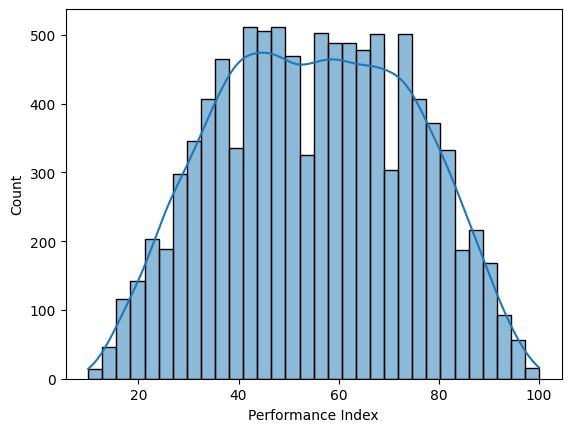

In [ ]:
sns.histplot(x=df['Performance Index'], kde=True)

In [ ]:
df['Performance Index'].skew()

np.float64(-0.0017400273072201125)

In [ ]:
#  0 -> centralized
# +1 -> np.right_shift
# -1 -> left
#agar skewness hoti hum karte log_transformation.

###Q5. Which columns of features are most connected to the target feature performance_index?

In [ ]:
temp = df.copy()

In [ ]:
temp['Extracurricular Activities'] = temp['Extracurricular Activities'].map({"Yes":1, "No":0})

<Axes: >

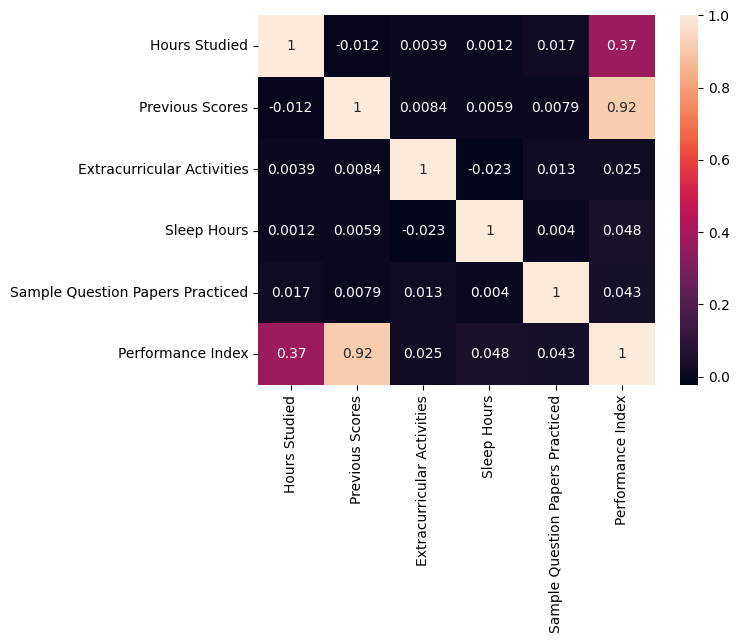

In [ ]:
sns.heatmap(temp.corr(), annot=True)

###Q6. Does Studying more hours give a better score make a scatterplot for this

<Axes: xlabel='Hours Studied', ylabel='Performance Index'>

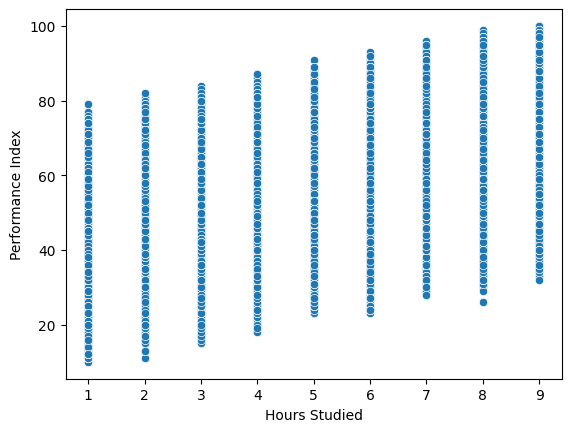

In [ ]:
sns.scatterplot(x=df['Hours Studied'],y=df['Performance Index'])

In [ ]:
df = df.drop_duplicates()

In [ ]:
df

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_temp = df.copy()

In [ ]:
df_temp['Extracurricular Activities'] = df_temp['Extracurricular Activities'].map({"Yes":1, "No":0})

In [ ]:
df_temp

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,1,9,1,91.0
1,4,82,0,4,2,65.0
2,8,51,1,7,2,45.0
3,5,52,1,5,2,36.0
4,7,75,0,8,5,66.0
...,...,...,...,...,...,...
9995,1,49,1,4,2,23.0
9996,7,64,1,8,5,58.0
9997,6,83,1,8,5,74.0
9998,9,97,1,7,0,95.0


In [ ]:
#X = Input features
#y = Output features

X = df_temp.drop(columns=["Performance Index"]) #-> Input Feature.
y = df_temp['Performance Index'] #->Output Feature.

In [ ]:
y

,Performance Index
0,91.0
1,65.0
2,45.0
3,36.0
4,66.0
...,...
9995,23.0
9996,58.0
9997,74.0
9998,95.0


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42) #random_state - 42 times random rows suffel karega
#X_train -> patterns extract recofnise konse target column ki acc ko inrease kr rahe hai

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
linearModel = LinearRegression()
#linearModel -> object of class LinearRegression

In [ ]:
#Train the LinearModel on Training set
linearModel.fit(X_train, y_train)

LinearRegression()

In [ ]:
#predictions on the unseen data
y_pred = linearModel.predict(X_test)

Model Exalution
MSE,MAE,r2_Score

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
mean_squared_error(y_test,y_pred)

4.326180232071975

In [ ]:
mean_absolute_error(y_test, y_pred)

1.6461997455341877

In [ ]:
r2_score(y_test, y_pred)#testing acc

0.9881593003934889

In [ ]:
y_train_pred = linearModel.predict(X_train)

In [ ]:
#Training acc
r2_score(y_test,y_pred)

0.9881593003934889